# Experimento preliminar — detecção de bordas em avarias de lataria

Objetivo (M1): verificar se filtros clássicos de PDI (Canny, Sobel) sobre imagem em escala de cinza e HSV conseguem isolar padrões visuais de arranhões e amassados em uma única foto, sem depender de comparação antes/depois.

Pipeline testado aqui: pré-processamento (cinza + HSV) → filtro de bordas (Canny/Sobel) → segmentação preliminar → destaque do dano (bounding box).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

INPUT_DIR = Path("../images/input")
RESULTS_DIR = Path("../images/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EXTENSOES = (".jpg", ".jpeg", ".png", ".webp")
image_paths = sorted(p for p in INPUT_DIR.iterdir() if p.suffix.lower() in EXTENSOES)
print(f"{len(image_paths)} imagens encontradas em {INPUT_DIR}")

22 imagens encontradas em ..\images\input


## Pré-processamento e filtro de bordas

Para cada imagem: conversão para escala de cinza e HSV, suavização (para reduzir ruído/textura da pintura) e detecção de bordas com Canny e Sobel.

In [2]:
def processar_imagem(caminho, canny_low=50, canny_high=150):
    img_bgr = cv2.imread(str(caminho))
    if img_bgr is None:
        raise ValueError(f"Nao foi possivel carregar {caminho}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cinza = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    cinza_suave = cv2.GaussianBlur(cinza, (5, 5), 0)
    canny = cv2.Canny(cinza_suave, canny_low, canny_high)

    sobel_x = cv2.Sobel(cinza_suave, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(cinza_suave, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.magnitude(sobel_x, sobel_y)
    sobel = np.uint8(np.clip(sobel_mag / (sobel_mag.max() + 1e-6) * 255, 0, 255))

    return {
        "rgb": img_rgb,
        "cinza": cinza,
        "hsv": hsv,
        "canny": canny,
        "sobel": sobel,
    }


def destacar_candidatos(canny, img_rgb, area_min=150):
    bordas_dilatadas = cv2.dilate(canny, np.ones((5, 5), np.uint8), iterations=2)
    contornos, _ = cv2.findContours(bordas_dilatadas, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    saida = img_rgb.copy()
    caixas = []
    for c in contornos:
        if cv2.contourArea(c) < area_min:
            continue
        x, y, w, h = cv2.boundingRect(c)
        caixas.append((x, y, w, h))
        cv2.rectangle(saida, (x, y), (x + w, y + h), (255, 0, 0), 3)

    return saida, caixas

## Visualização em algumas imagens de exemplo

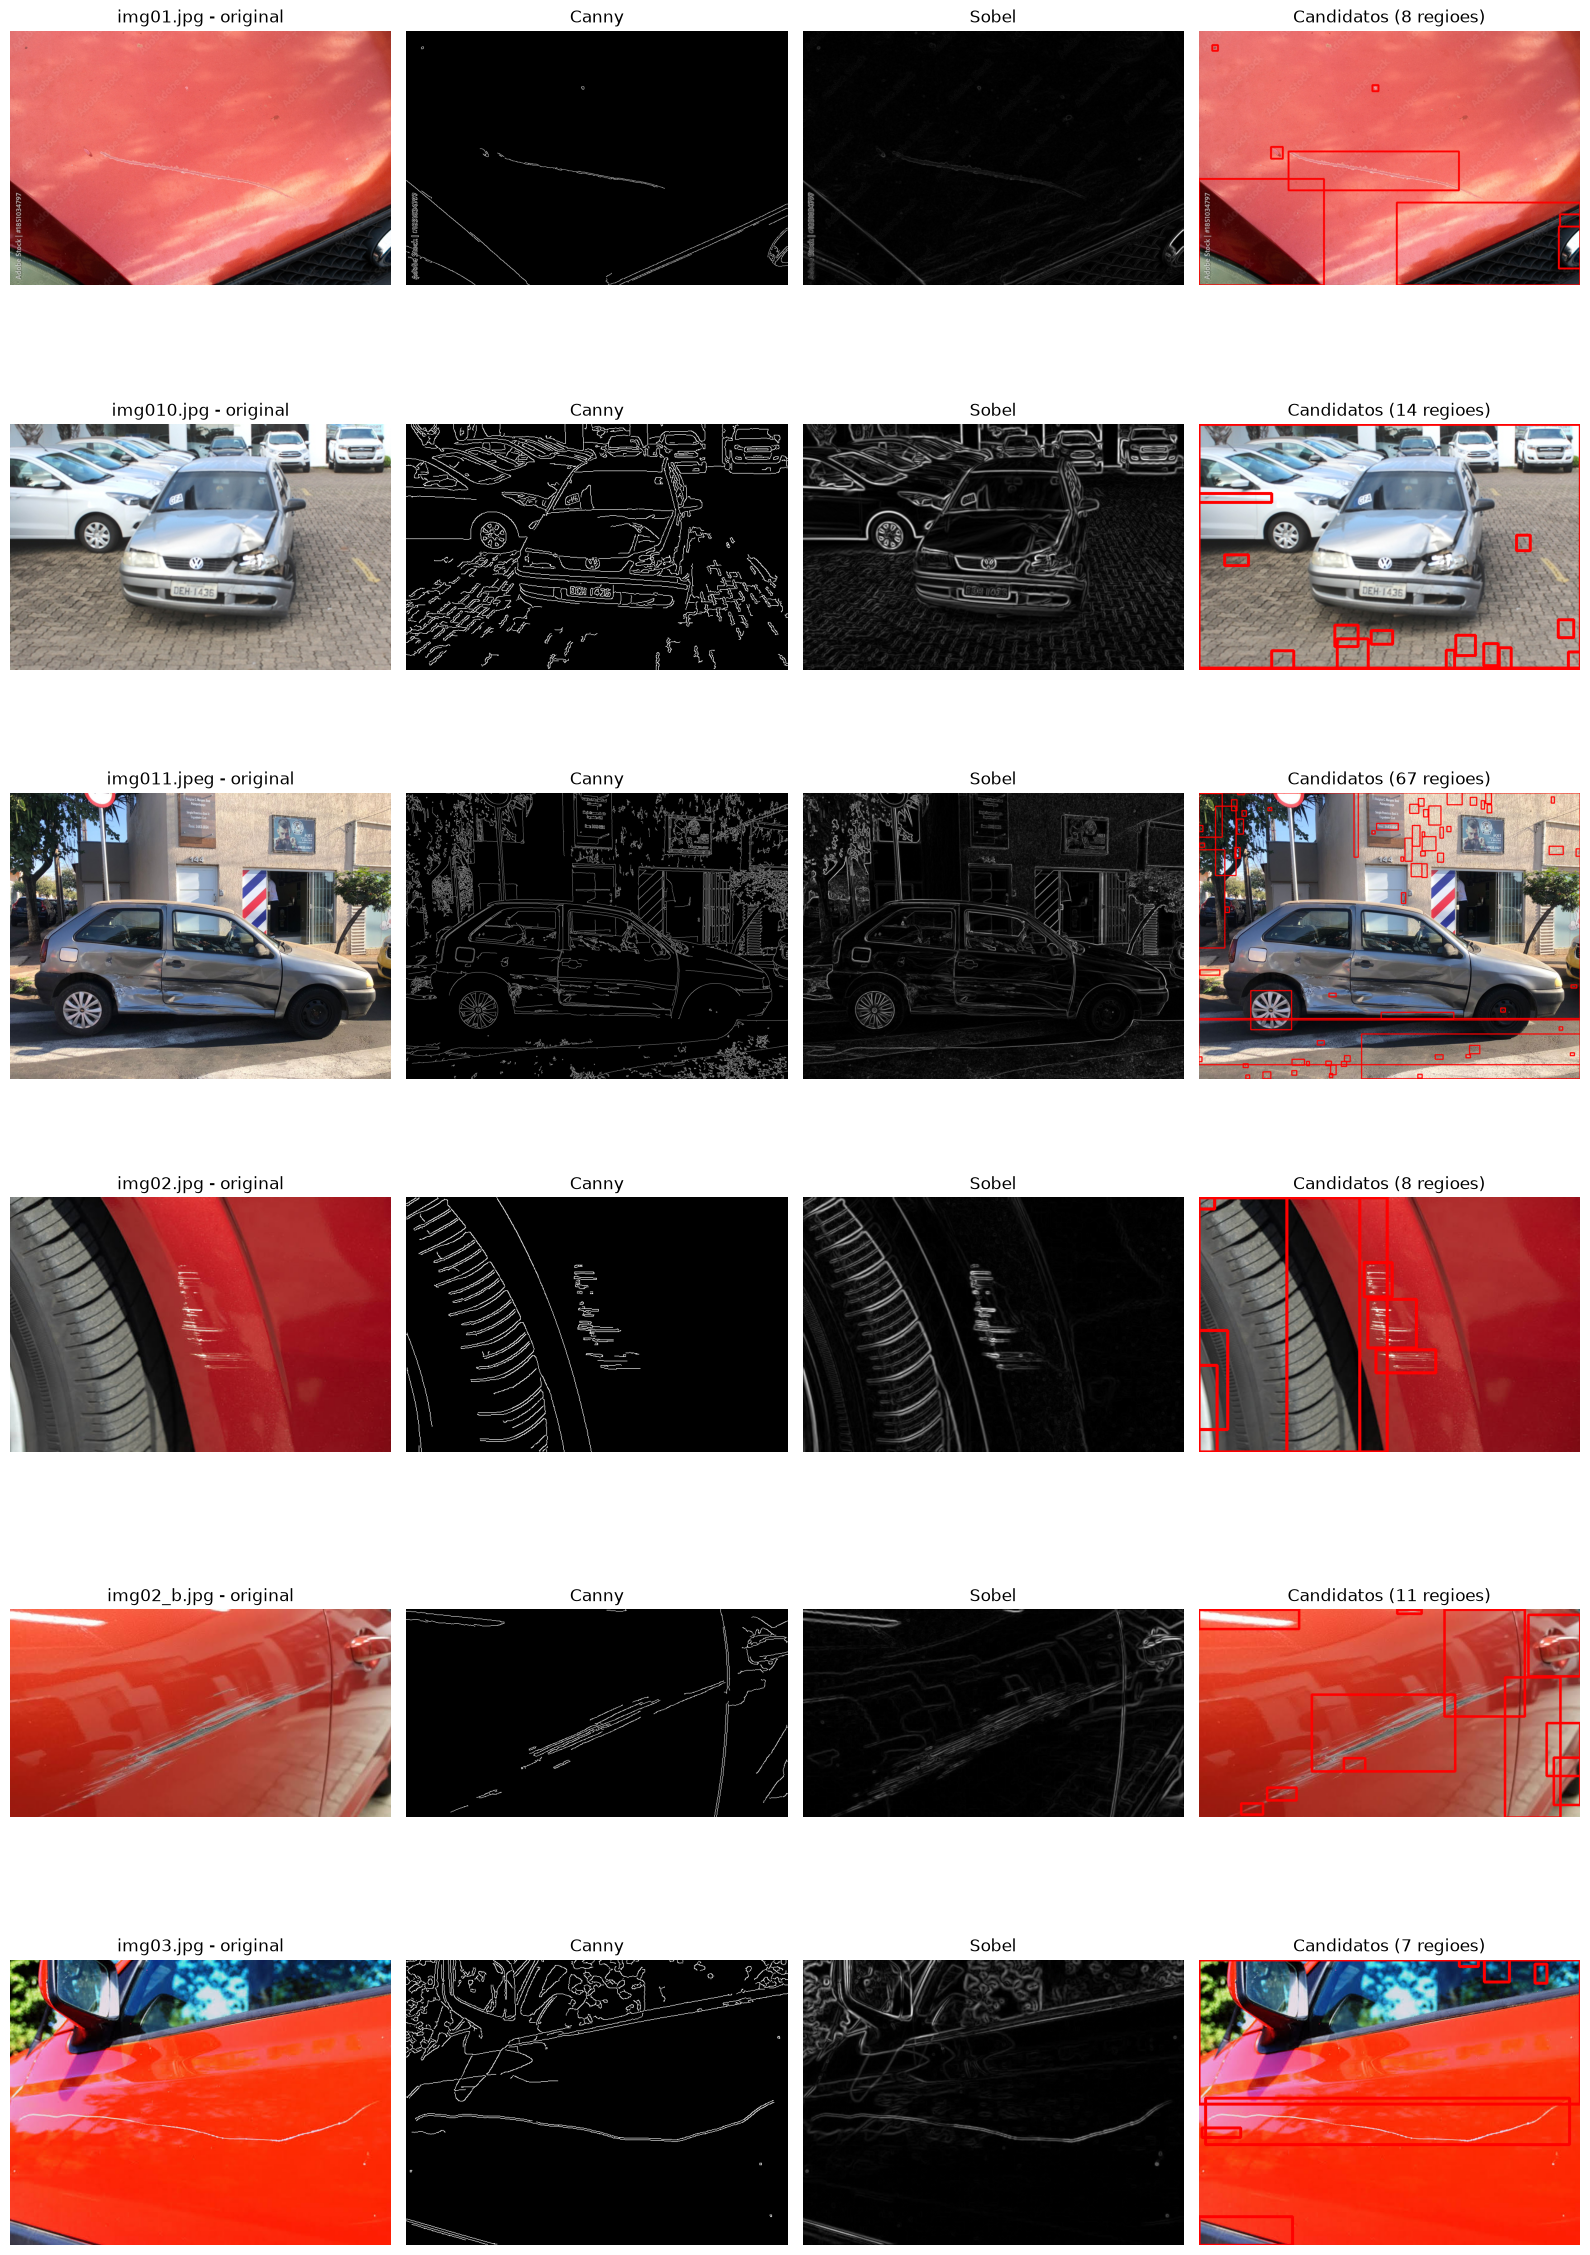

In [3]:
AMOSTRA = image_paths[:6]

fig, eixos = plt.subplots(len(AMOSTRA), 4, figsize=(16, 4 * len(AMOSTRA)))

for linha, caminho in enumerate(AMOSTRA):
    r = processar_imagem(caminho)
    destaque, caixas = destacar_candidatos(r["canny"], r["rgb"])

    eixos[linha, 0].imshow(r["rgb"])
    eixos[linha, 0].set_title(f"{caminho.name} - original")

    eixos[linha, 1].imshow(r["canny"], cmap="gray")
    eixos[linha, 1].set_title("Canny")

    eixos[linha, 2].imshow(r["sobel"], cmap="gray")
    eixos[linha, 2].set_title("Sobel")

    eixos[linha, 3].imshow(destaque)
    eixos[linha, 3].set_title(f"Candidatos ({len(caixas)} regioes)")

    for col in range(4):
        eixos[linha, col].axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "amostra_pipeline_preliminar.png", dpi=120)
plt.show()

## Processamento de todo o conjunto e gravação dos resultados

Salva, para cada imagem de entrada, o resultado do Canny e o destaque de candidatos em `images/results/`.

In [4]:
resumo = []

for caminho in image_paths:
    r = processar_imagem(caminho)
    destaque, caixas = destacar_candidatos(r["canny"], r["rgb"])

    cv2.imwrite(str(RESULTS_DIR / f"{caminho.stem}_canny.png"), r["canny"])
    cv2.imwrite(
        str(RESULTS_DIR / f"{caminho.stem}_candidatos.png"),
        cv2.cvtColor(destaque, cv2.COLOR_RGB2BGR),
    )

    resumo.append({"imagem": caminho.name, "regioes_candidatas": len(caixas)})

resumo

[{'imagem': 'img01.jpg', 'regioes_candidatas': 8},
 {'imagem': 'img010.jpg', 'regioes_candidatas': 14},
 {'imagem': 'img011.jpeg', 'regioes_candidatas': 67},
 {'imagem': 'img02.jpg', 'regioes_candidatas': 8},
 {'imagem': 'img02_b.jpg', 'regioes_candidatas': 11},
 {'imagem': 'img03.jpg', 'regioes_candidatas': 7},
 {'imagem': 'img04.jpg', 'regioes_candidatas': 5},
 {'imagem': 'img05.jpg', 'regioes_candidatas': 12},
 {'imagem': 'img06.jpg', 'regioes_candidatas': 4},
 {'imagem': 'img07.jpg', 'regioes_candidatas': 18},
 {'imagem': 'img08.jpg', 'regioes_candidatas': 3},
 {'imagem': 'img089.jpg', 'regioes_candidatas': 9},
 {'imagem': 'img09.jpg', 'regioes_candidatas': 23},
 {'imagem': 'img12.jpeg', 'regioes_candidatas': 6},
 {'imagem': 'img13.jpg', 'regioes_candidatas': 5},
 {'imagem': 'img14.webp', 'regioes_candidatas': 9},
 {'imagem': 'img15.jpeg', 'regioes_candidatas': 29},
 {'imagem': 'img16.jpg', 'regioes_candidatas': 13},
 {'imagem': 'img17.jpg', 'regioes_candidatas': 5},
 {'imagem': 'i

## Observações preliminares

- O Canny isola bem os riscos lineares mais evidentes (bordas finas e alongadas), consistente com o que se esperava para arranhões.
- A etapa de "destaque de candidatos" (contornos das bordas dilatadas) ainda gera bastante falso positivo: reflexos de luz, sombras e bordas naturais da lataria (frisos, maçanetas, para-choques) também viram bounding boxes.
- Isso confirma a dúvida já registrada em `docs/proposta.md` (seção 4): o limiar de área sozinho não é suficiente para separar dano real de sombra/reflexo — a etapa de filtragem (seção 4 da proposta) vai precisar de critérios adicionais de forma/orientação da região, não só tamanho.
- Próximo passo (M2): usar o canal HSV (já calculado, ainda não incorporado à segmentação) para tentar diferenciar reflexo/brilho de amassado real, e refinar os critérios de filtragem dos bounding boxes.